## Paso 0 · Ver la base

Qué variables hay, en qué se gasta y con qué cobertura temporal.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image

from src import config as cfg
from src import data_io, explorar, viz

pd.set_option("display.width", 200)
viz.aplicar_estilo()

ruta, origen = data_io.resolver_fuente()
df = data_io.cargar(ruta)

print(f"Fuente: {origen}  |  {len(df):,} filas x {df.shape[1]} columnas")

  Sin CSV de Kaggle ni credenciales: se usan datos sinteticos.


Fuente: sintetico  |  156,194 filas x 13 columnas


### Variables

Tipo, faltantes, cardinalidad, rango y un valor de ejemplo por columna.

Con fuente sintética aparece `_segmento_real`, que no existe en el dataset de
Kaggle: es el segmento latente con el que se generó cada cliente, y sirve para
auditar después si la segmentación logra recuperarlo.

In [2]:
explorar.perfil_columnas(df)

,tipo,nulos,pct_nulos,unicos,rango,ejemplo
columna,,,,,,
trans_date_trans_time,datetime64[ns],0,0.0,155903,2019-01-01 a 2020-12-30,2019-01-01 00:08:24
cc_num,int64,0,0.0,600,"4,000,000,000,000,000.00 a 4,000,000,004,743,4...",4000000004418802
merchant,category,0,0.0,154,,fraud_shopping_pos_8
category,category,0,0.0,14,,shopping_pos
amt,float64,0,0.0,24656,"2.44 a 2,910.00",94.23
gender,category,0,0.0,2,,M
city,category,0,0.0,313,,PA_city_2
state,category,0,0.0,10,,PA
city_pop,int32,0,0.0,596,"150.00 a 2,115,742.00",231198


### En qué se gasta

Ojo a la brecha entre `pct_transacciones` y `pct_monto`: una categoría puede
ser muy frecuente y poco relevante en valor, o al revés. Medir la composición
sobre el **monto** y no sobre el conteo es una decisión con consecuencias.

In [3]:
#| label: tbl-categorias
#| tbl-cap: "Volumen y valor por categoría."
explorar.resumen_categorias(df)

,transacciones,monto_total,ticket_medio,ticket_mediano,pct_transacciones,pct_monto
Viajes,8897,3145534.10,353.55,295.00,5.70,26.97
Compras (online),13557,1191584.19,87.89,67.81,8.68,10.22
Supermercado (presencial),19094,1000130.97,52.38,43.38,12.22,8.58
Compras (presencial),9423,993915.04,105.48,84.17,6.03,8.52
Hogar,13031,904969.48,69.45,56.89,8.34,7.76
Entretenimiento,12247,752036.82,61.41,46.55,7.84,6.45
Restaurantes,12335,672729.82,54.54,41.78,7.90,5.77
Salud y bienestar,11953,661171.63,55.31,45.00,7.65,5.67
Ninos y mascotas,13241,650048.27,49.09,40.55,8.48,5.57
Combustible y transporte,13904,468705.69,33.71,27.55,8.90,4.02


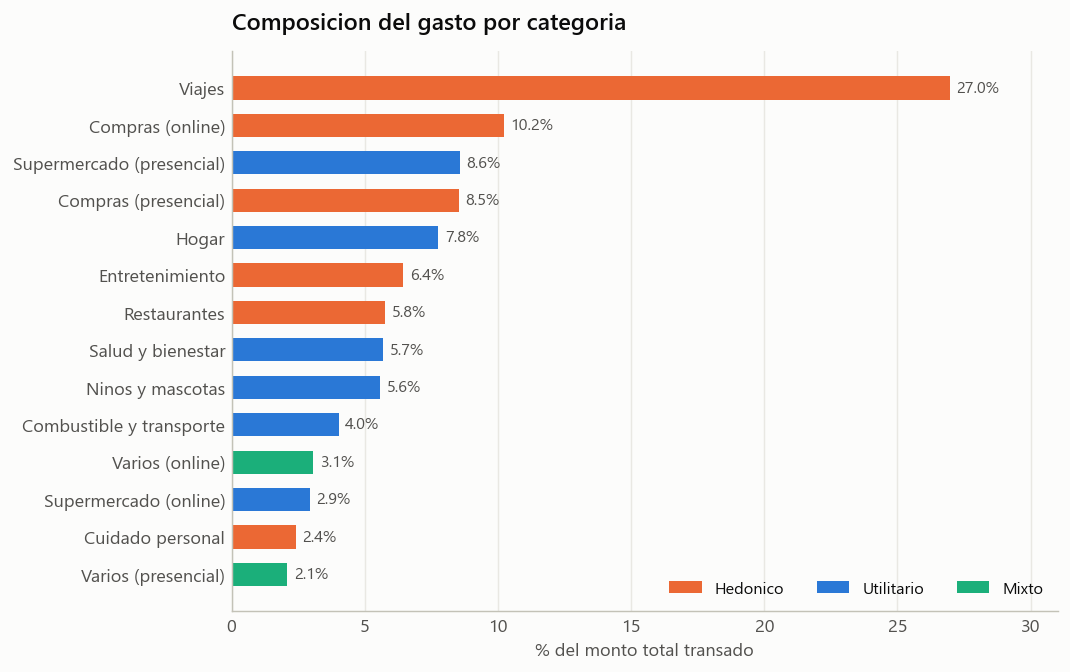

In [4]:
#| label: fig-composicion
#| fig-cap: "Peso de cada categoría en el monto total, coloreado por tipo de gasto."
viz.composicion_categorias(df)
Image(str(cfg.FIGURES / "01_composicion_categorias.png"))

### Cobertura temporal

Meses vacíos o con volumen anómalo contaminarían cualquier lectura estacional.

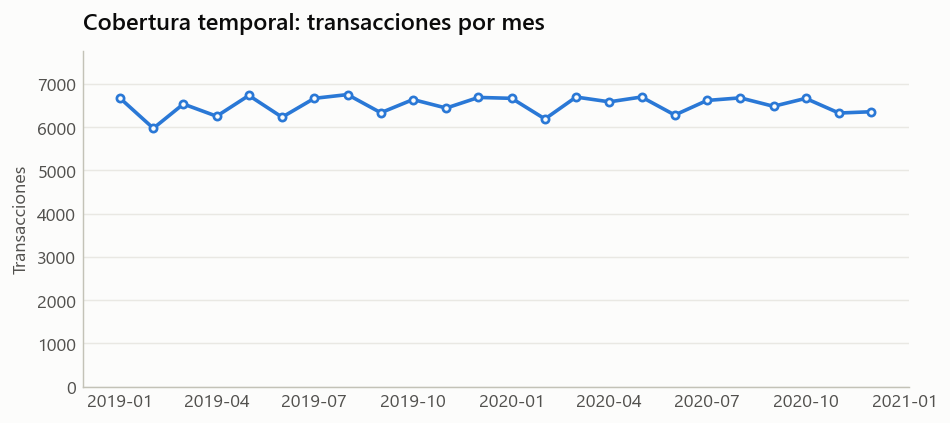

In [5]:
viz.cobertura_temporal(df)
Image(str(cfg.FIGURES / "00b_cobertura_temporal.png"))